# Attrition des Employés (Churn)

## Prédiction du départ des employés dans une entreprise

### Objectif du projet

L’objectif de ce projet est de construire un modèle de Machine Learning capable de prédire si un employé risque de quitter l’entreprise ou non.

Cette étude permet d’anticiper les départs, améliorer la satisfaction des employés, et d’aider le service RH dans la prise de décision.

Le projet suit les différentes étapes classiques :
1. Compréhension des données
2. Analyse exploratoire des données (EDA)
3. Préparation des données
4. Modélisation et entraînement
5. Évaluation et interprétation des résultats

In [1]:
# Importation des bibliothèques

# Manipulation et analyse des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Modèles de classification
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Chargement du Dataset

Le dataset utilisé contient plusieurs informations concernant les employés, la variable cible est : Attrition
    - Yes → l’employé quitte l’entreprise
    - No → l’employé reste dans l’entreprise

Les autres variables représentent les variables explicatives utilisées pour prédire l’attrition.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Dimension du dataset
df.shape

(1470, 35)

Notre dataset contient donc 1470 lignes (employés) et 35 colonnes (variables)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Nous remarquons que le dataset contient 26 variables numériques et 9 variables catégorielles.
Nous observons également que toutes les colonnes contiennent 1470 valeurs non nulles.
Cela signifie qu’aucune donnée manquante n’est présente dans le dataset.

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.duplicated().sum()

np.int64(0)

Le dataset ne contient ni valeurs manquantes ni doublons.

# Analyse Exploratoire des Données (EDA)

L’analyse exploratoire permet de mieux comprendre les relations entre les variables et l’attrition des employés.


# Distribution de la variable cible

Nous commençons par analyser la variable cible afin de vérifier la répartition des classes.

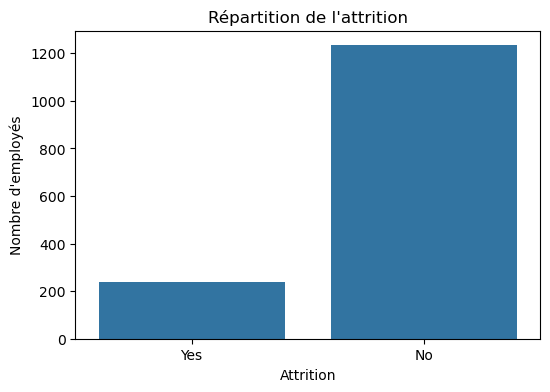

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df
)

plt.title("Répartition de l'attrition")
plt.xlabel("Attrition")
plt.ylabel("Nombre d'employés")

plt.show()

Nous remarquons que la majorité des employés restent dans l’entreprise. Le dataset est donc déséquilibré.

Cette observation est importante car un déséquilibre de classes peut influencer les performances des modèles de classification.

Pour cette raison :
- nous utiliserons `stratify=y` afin de conserver le même équilibre de classes dans le Train Set et le Test Set,
- ainsi que `class_weight="balanced"` pour certains modèles afin d’accorder plus d’importance à la classe minoritaire.

# Attrition et heures supplémentaires

Nous analysons maintenant l’impact des heures supplémentaires sur l’attrition.

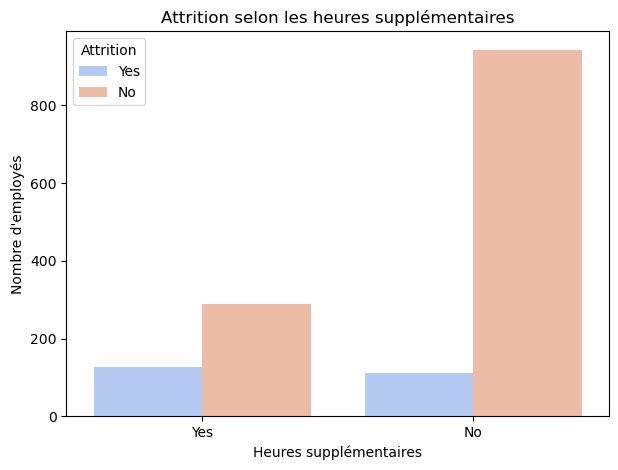

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df,
    palette="coolwarm"
)

plt.title("Attrition selon les heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Nombre d'employés")

plt.show()


Nous observons que les employés effectuant des heures supplémentaires quittent plus fréquemment l’entreprise.
La variable `OverTime` semble donc particulièrement pertinente pour la prédiction.

# Salaire et attrition

Nous analysons ensuite la relation entre le salaire mensuel et le départ des employés.

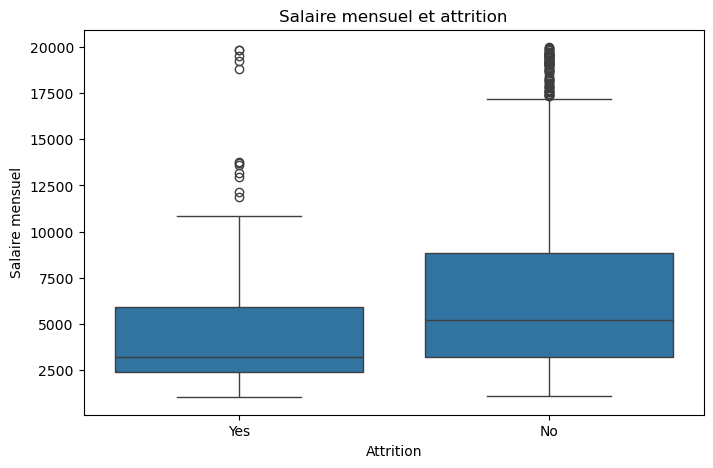

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df,
)

plt.title("Salaire mensuel et attrition")
plt.xlabel("Attrition")
plt.ylabel("Salaire mensuel")

plt.show()

## Interprétation

Nous remarquons que les employés ayant un salaire plus faible semblent davantage susceptibles de quitter l’entreprise.

Nous remarquons également plusieurs valeurs extrêmes, ce qui montre une forte dispersion des salaires dans l’entreprise.

# Analyse des variables numériques

Afin de mieux comprendre la distribution des variables numériques et détecter les valeurs aberrantes, nous utilisons des boxplots.

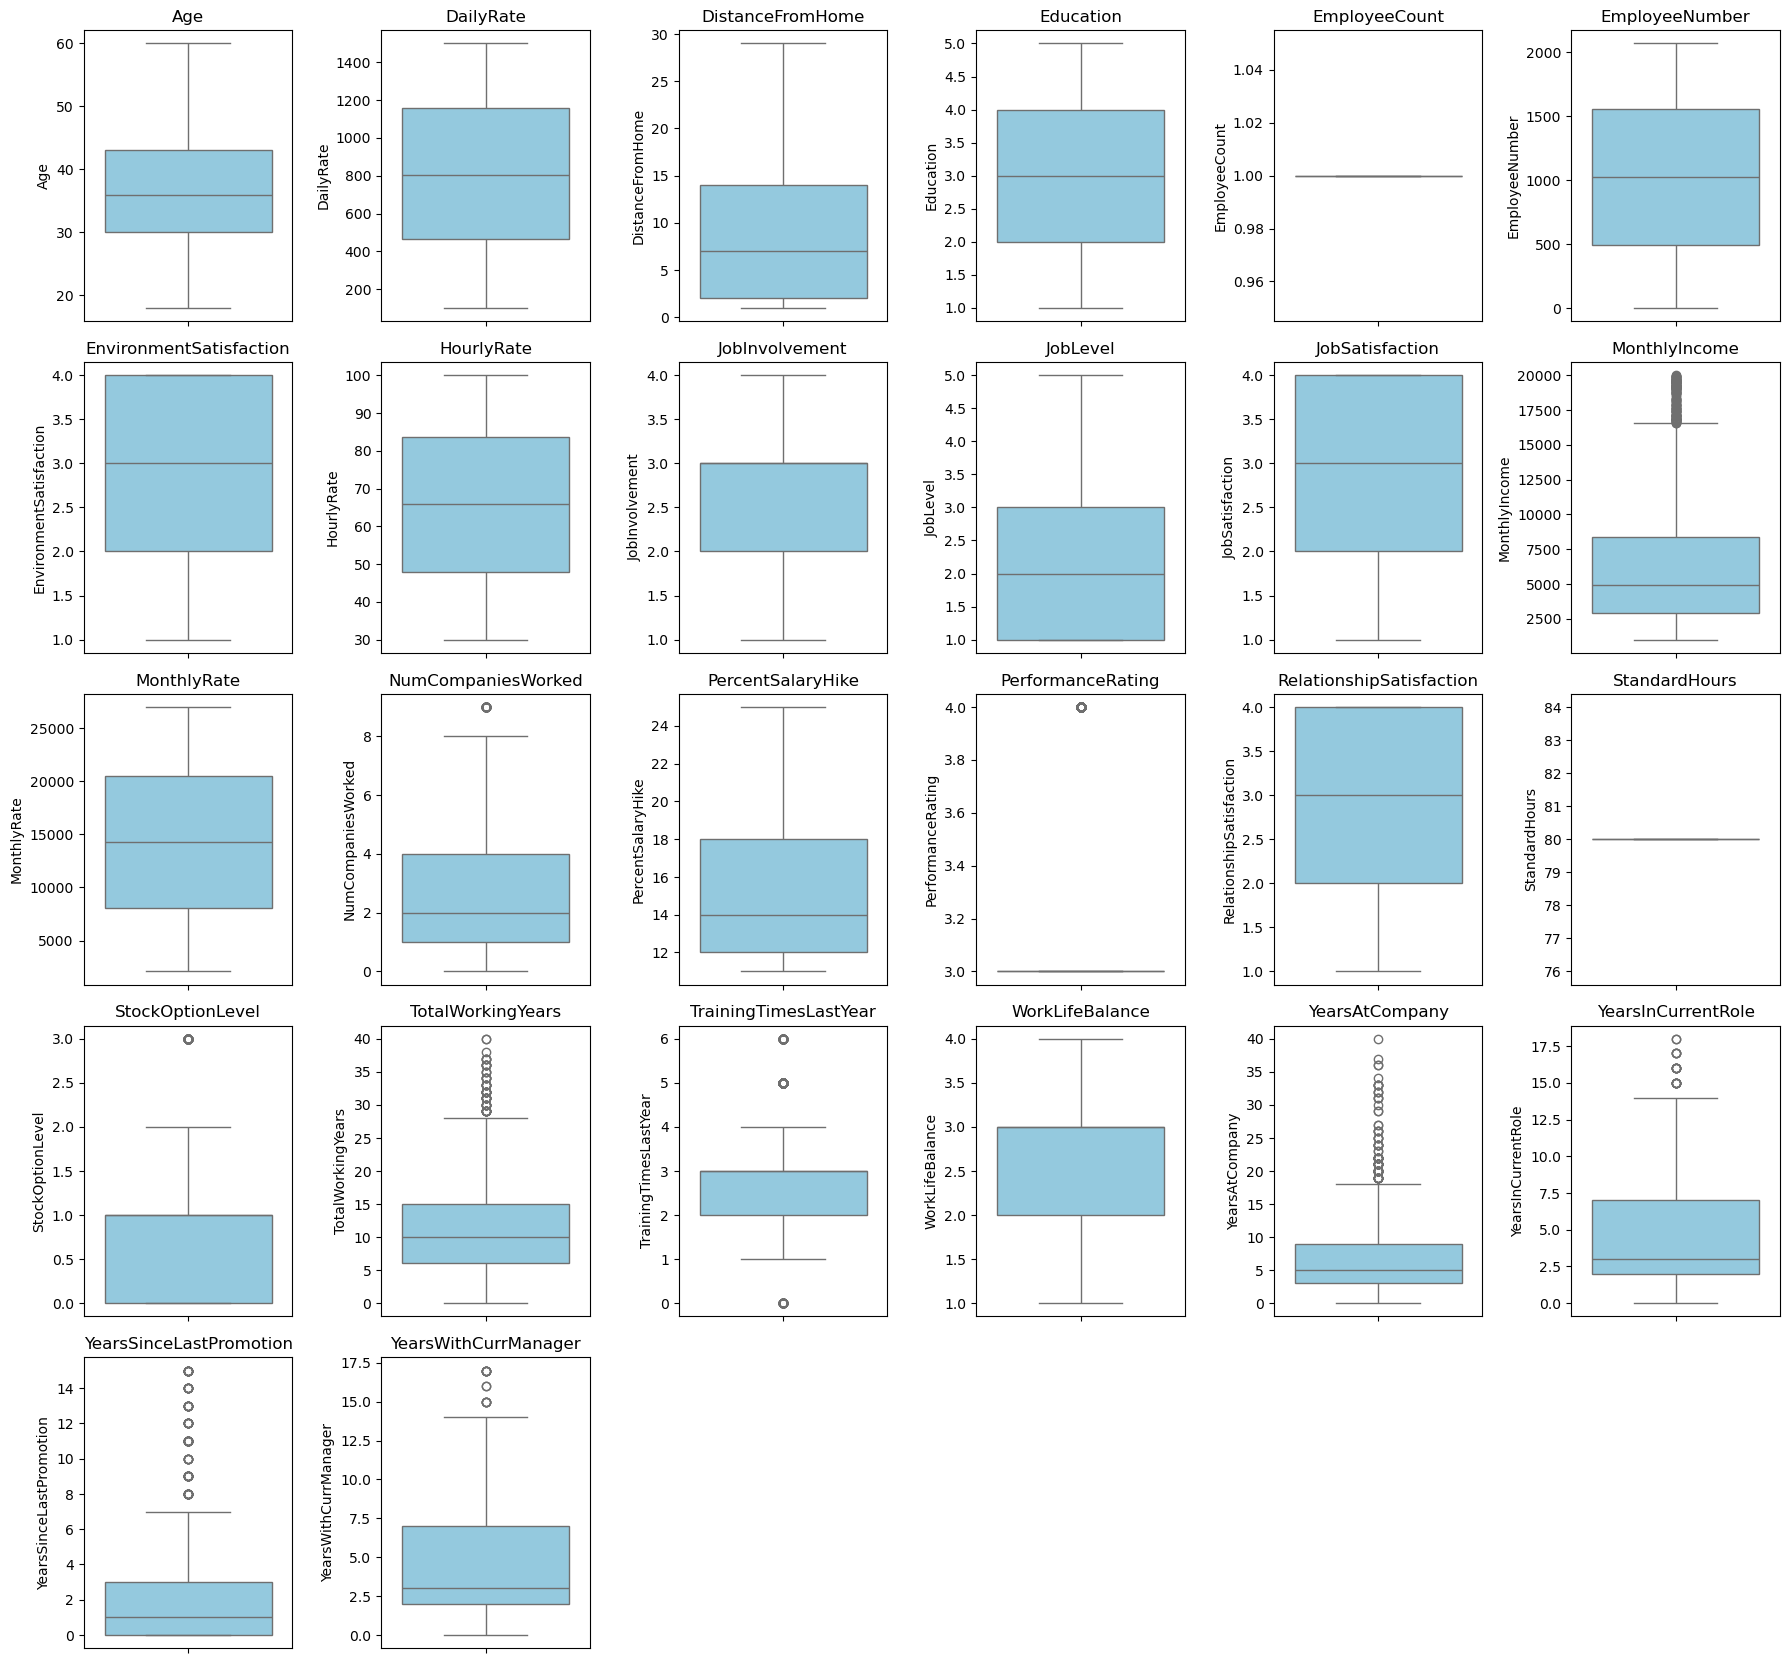

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18,20))

for i, col in enumerate(numeric_cols, 1):

    plt.subplot(6, 6, i)

    sns.boxplot(
        y=df[col],
        color="skyblue"
    )

    plt.title(col)

plt.tight_layout()

plt.show()

## Interprétation

Nous observons la présence de valeurs aberrantes dans certaines variables comme MonthlyIncome, DistanceFromHome, YearsAtCompany.

Ces valeurs peuvent influencer certains modèles sensibles aux grandes variations.

# Matrice de corrélation

Nous analysons maintenant les relations entre les variables numériques à l’aide d’une matrice de corrélation.

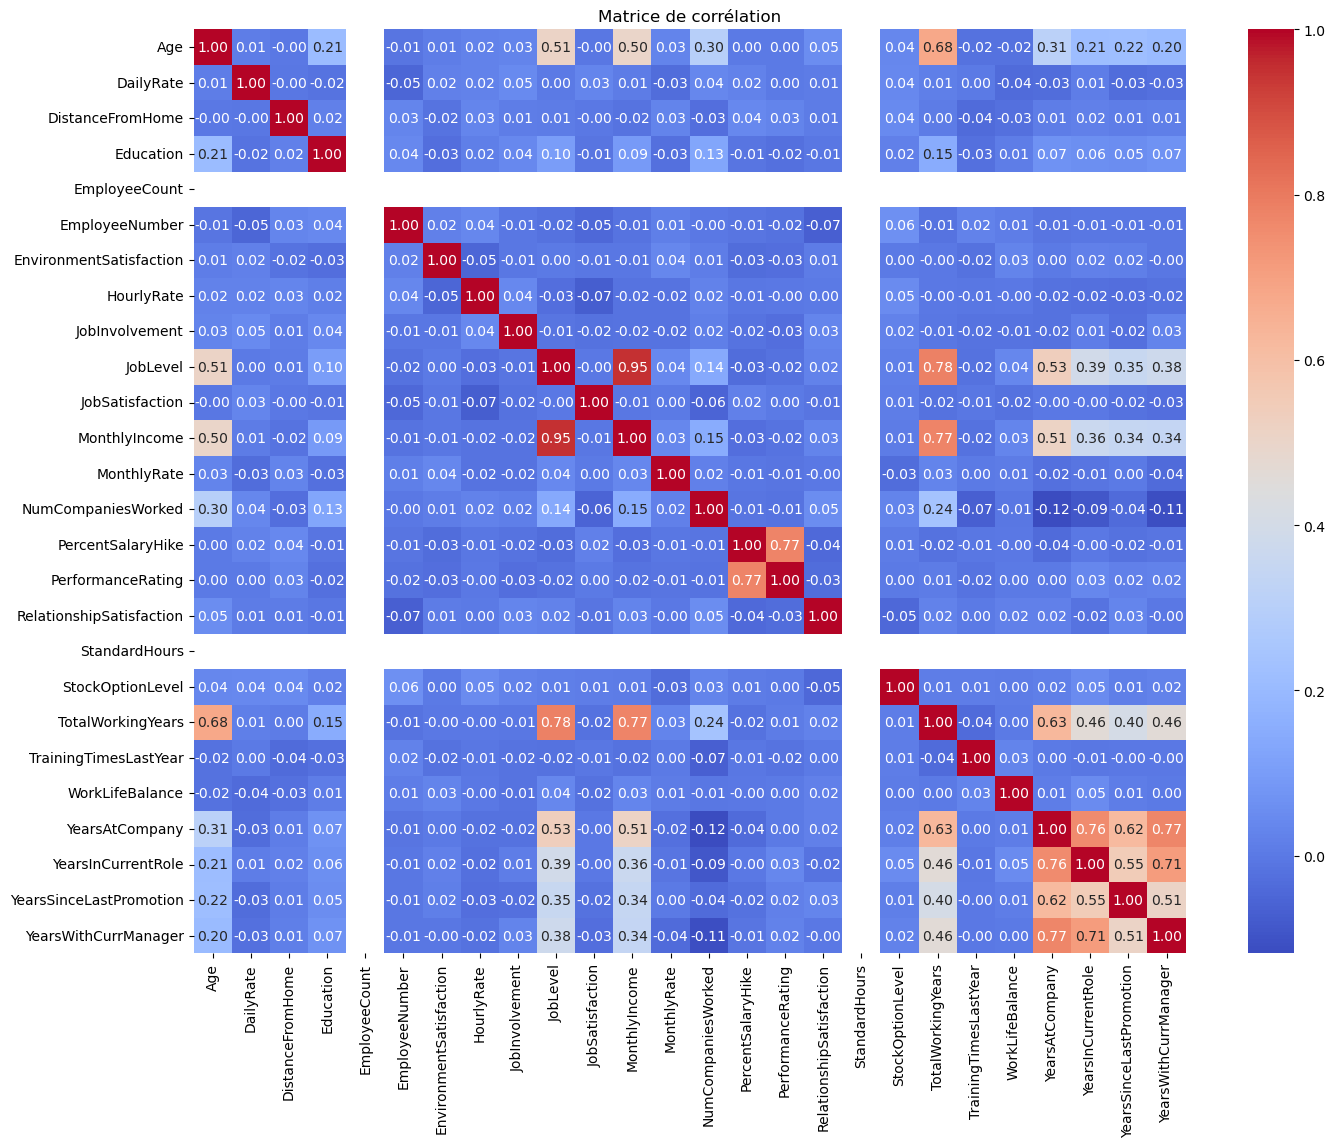

In [12]:
plt.figure(figsize=(16,12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

## Interprétation

La matrice de corrélation montre plusieurs relations intéressantes entre les variables.

Nous remarquons par exemple que :
- `MonthlyIncome` et `JobLevel` présentent une forte corrélation positive, ce qui est logique puisque les employés ayant un niveau hiérarchique élevé possèdent généralement un salaire plus important.

Cette forte corrélation peut entraîner une certaine redondance d’information.


# Préparation des données

Après l’analyse exploratoire, nous préparons maintenant les données afin qu’elles puissent être utilisées par les algorithmes de Machine Learning.

Cette étape est essentielle car les modèles ne peuvent pas exploiter directement certaines données brutes, notamment les variables textuelles.

# Suppression des colonnes inutiles

Certaines colonnes n’apportent pas d’information utile pour la prédiction de l’attrition.

In [13]:
df = df.drop(
    [
        "EmployeeNumber",
        "EmployeeCount",
        "StandardHours",
        "Over18"
    ],
    axis=1
)

## Justification

Ces variables sont supprimées car elles n’apportent donc aucune information utile au modèle :

- `EmployeeNumber` représente uniquement un identifiant unique pour chaque employé,
- `EmployeeCount`, `StandardHours` et `Over18` possèdent des valeurs constantes.


# Encodage des variables catégorielles

Les algorithmes de Machine Learning ne peuvent pas traiter directement les données textuelles.

Les variables catégorielles doivent donc être converties en valeurs numériques.

In [14]:
for col in df.select_dtypes(include="object").columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

## Justification

Le `LabelEncoder` permet de transformer les catégories textuelles en valeurs numériques compréhensibles par les modèles.
- Yes ->  1
- No -> 0

In [15]:
# Séparation des variables explicatives et de la variable cible
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

- `X` contient les variables utilisées pour effectuer les prédictions
- `y` contient la variable cible à prédire.

# Division des données : Train / Test

Les données sont divisées afin d`entraîner les modèles sur une partie des données puis évaluer leurs performances sur des données jamais vues auparavant.

Nous utilisons :
- 80% des données pour l’entraînement,
- 20% pour le test.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Le paramètre `stratify=y` permet de conserver la même proportion de classes dans l’ensemble d’entraînement et l’ensemble de test.
Cela est particulièrement important puisque le dataset est déséquilibré.

# Normalisation des données

Certaines variables possèdent des échelles très différentes.
Par exemple :
- `MonthlyIncome` peut atteindre plusieurs milliers,
- tandis que `JobLevel` varie seulement entre 1 et 5.

La normalisation permet donc d’éviter qu’une variable domine les autres simplement à cause de son amplitude.

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Modélisation

Nous allons maintenant entraîner plusieurs modèles de classification afin de comparer leurs performances.

L’objectif est d’identifier le modèle le plus adapté à la prédiction de l’attrition des employés.

In [18]:
# Régression Logistique

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


Ce modèle est simple, rapide et facilement interprétable.
Il constitue un bon point de comparaison pour les modèles plus complexes.

Le paramètre `class_weight="balanced"` permet de mieux gérer le déséquilibre des classes.

In [19]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)




Random Forest gère bien les relations complexeset permet d’obtenir l’importance des variables.


In [20]:
# Gradient Boosting
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)


Ce modèle est souvent performant sur les problèmes de classification grâce à son apprentissage progressif des erreurs.

Chaque nouvel arbre cherche à corriger les erreurs des arbres précédents, ce qui permet généralement d’améliorer les performances.

# Validation Croisée

Afin de vérifier la stabilité du modèle, nous utilisons une validation croisée.

In [21]:
cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1-score moyen :", cv_scores.mean())

F1-score moyen : 0.23794466403162057



La validation croisée permet de vérifier que les performances du modèle ne dépendent pas uniquement d’un seul découpage des données.

Un score stable indique généralement une meilleure capacité de généralisation du modèle.

# Évaluation des modèles

Les modèles sont évalués à l’aide de plusieurs métriques :
- Accuracy,
- F1-score,
- Classification Report,
- Matrice de confusion.

L’objectif est d’évaluer non seulement la précision globale, mais également la capacité des modèles à détecter correctement les employés à risque.

In [22]:
def evaluate_model(name, y_pred):

    print(f"\n{name}")

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("F1-score :", f1_score(y_test, y_pred))

    print("\nClassification Report :\n")

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )

    plt.title(f"Matrice de confusion - {name}")

    plt.xlabel("Prédictions")

    plt.ylabel("Valeurs réelles")

    plt.show()


Logistic Regression
Accuracy : 0.7517006802721088
F1-score : 0.496551724137931

Classification Report :

              precision    recall  f1-score   support

           0       0.94      0.75      0.84       247
           1       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



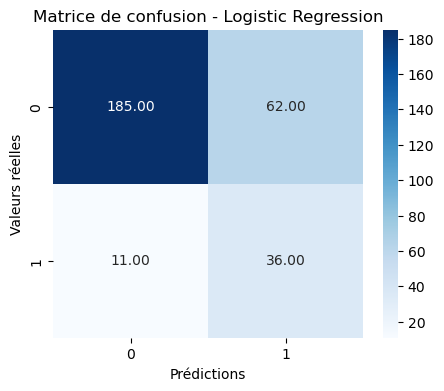

In [23]:
# Évaluation de la Régression Logistique
evaluate_model("Logistic Regression", y_pred_lr)



Random Forest
Accuracy : 0.8333333333333334
F1-score : 0.14035087719298245

Classification Report :

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



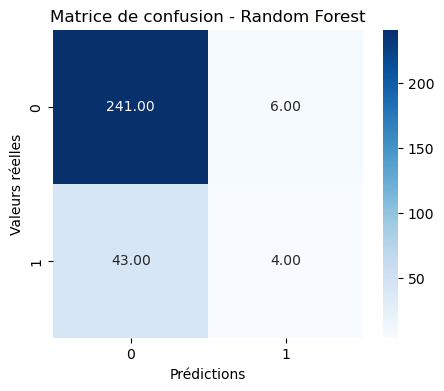

In [24]:
# Évaluation du Random Forest
evaluate_model("Random Forest", y_pred_rf)


Gradient Boosting
Accuracy : 0.8469387755102041
F1-score : 0.2857142857142857

Classification Report :

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.56      0.19      0.29        47

    accuracy                           0.85       294
   macro avg       0.71      0.58      0.60       294
weighted avg       0.82      0.85      0.81       294



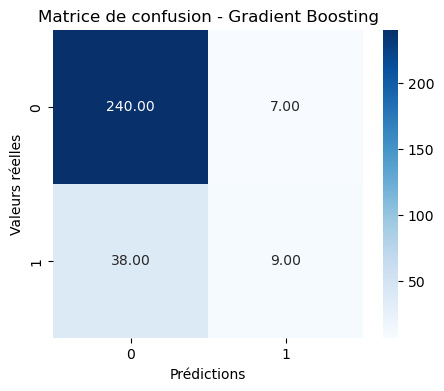

In [25]:
# Évaluation du Gradient Boosting
evaluate_model("Gradient Boosting", y_pred_gb)

# Comparaison des modèles

Afin de comparer les performances des différents modèles, nous regroupons les résultats dans un tableau récapitulatif.

In [26]:
results = pd.DataFrame({

    "Modèle": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],

    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results

,Modèle,Accuracy,F1-score
0,Logistic Regression,0.751701,0.496552
1,Random Forest,0.833333,0.140351
2,Gradient Boosting,0.846939,0.285714


## Interprétation

Les résultats permettent d’identifier le modèle offrant le meilleur compromis entre précision globale, capacité de généralisation, et détection correcte des employés à risque.

Contrairement à ce qui est souvent observé, la régression logistique offre ici les meilleures performances globales.

Cela montre qu’un modèle plus complexe n’est pas forcément meilleur dans tous les cas.

# Importance des variables

Cette étape permet d’identifier les variables ayant le plus d’impact sur la prédiction.

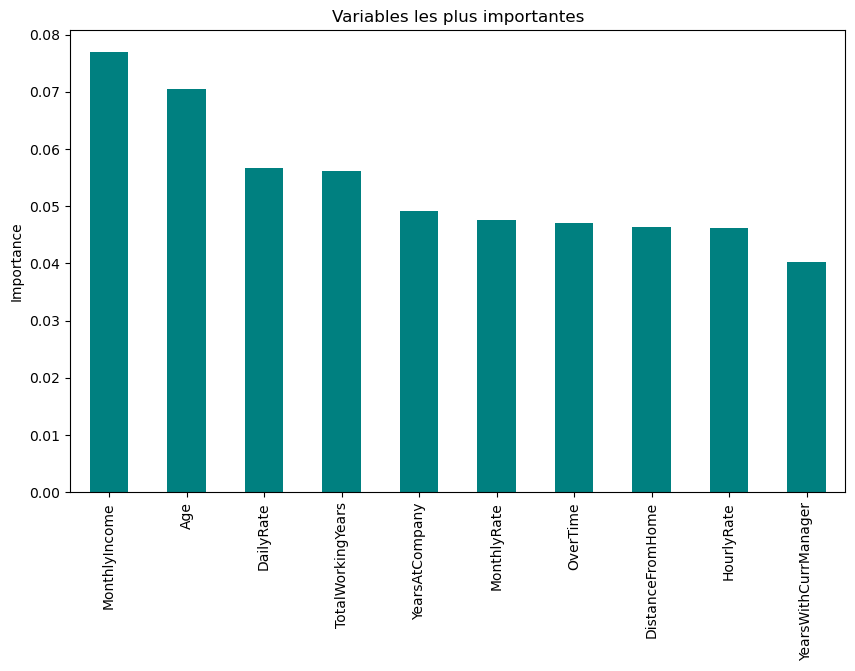

In [27]:
importances = rf.feature_importances_

features = pd.Series(
    importances,
    index=X.columns
)

top_features = features.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

top_features.plot(
    kind="bar",
    color="teal"
)

plt.title("Variables les plus importantes")

plt.ylabel("Importance")

plt.show()

## Interprétation

Les variables les plus importantes sont principalement liées :
- aux heures supplémentaires
- au salaire
- à la satisfaction au travail
- et à l’ancienneté

Ces résultats confirment les observations réalisées durant l’analyse exploratoire.

Nous remarquons donc une cohérence entre les visualisations de l’EDA et les résultats obtenus après modélisation

# Analyse métier

Les résultats montrent que les employés surchargés, sous-payés ou insatisfaits présentent un risque plus élevé de quitter l’entreprise.

Ces informations peuvent aider les ressources humaines à :
- améliorer les conditions de travail
- réduire les heures supplémentaires
- renforcer la satisfaction des employés
- et mettre en place des stratégies de fidélisation.

# Conclusion

Ce projet a permis de construire plusieurs modèles de Machine Learning capables de prédire l’attrition des employés.

Les différentes étapes ont permis de comprendre les données, d’identifier les variables importantes, d’entraîner plusieurs modèles, puis d’évaluer leurs performances

Les résultats montrent que la régression logistique offre les meilleures performances sur ce dataset, notamment grâce à une meilleure détection de la classe minoritaire.

Ce travail peut être utilisé dans un contexte réel afin d’aider les entreprises à :
- anticiper les départs
- réduire le turnover
- et améliorer la gestion des ressources humaines.